# 单条光谱离线处理过程展示

这个 notebook 对照当前 `raman.data` 的真实实现，展示单条光谱在离线阶段的处理顺序：

1. 读取原始光谱
2. 使用 AsLS 做基线校正（拟合时跳过 `bad_bands`）
3. 按配置裁剪波段
4. 在裁剪后的原始点上先删除 `bad_bands`
5. 只在有效目标波数坐标上插值
6. 用库函数 `preprocess_single_spectrum` 复核结果
7. 展示 `smooth` 通道的构建过程
8. 展示主通道默认使用的 `SNV` 标准化

注意：`python -m raman.data train` 和 `test` 落盘保存的是删除坏波段后、已在有效目标轴上对齐的光谱，
不是 SNV 后的结果；SNV 主要用于模型输入和绘图展示，而不是离线落盘值。

当前默认配置下，完整目标轴点数是 `862`，删除 `890~950 cm^-1` 坏波段后，最终有效目标轴点数是 `819`。
这与裁剪后原始采样点数不同；原始点数来自仪器采样轴，目标轴点数来自统一插值参考轴。


In [2]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Microsoft YaHei'
import numpy as np
import torch
import torch.nn.functional as F
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from raman.data.cli import ensure_dataset_layout
from raman.data.offline import asls_baseline, preprocess_single_spectrum
from raman.data.spectrum import (
    build_valid_mask,
    minmax_normalize,
    read_arc_data,
    snv,
)
from raman.data.build import DEFAULT_PIPELINE_CONFIG
from raman.data.profiles import COMMON_BAD_BANDS, get_profile
from raman.config import Config
from raman.data.input import build_sg_kernels, normalize_spectrum

sns.set_theme(style="whitegrid", context="talk", font="Microsoft YaHei")
plt.rcParams["figure.figsize"] = (10, 5)

DATASET_NAME = "细菌"
profile = get_profile(DATASET_NAME)  # 也可改成中文别名，例如 "细菌"
dataset_dir = ensure_dataset_layout(profile)
cfg = DEFAULT_PIPELINE_CONFIG
train_cfg = Config()
train_cfg.dataset_name = profile.dataset_name
BAD_BANDS = COMMON_BAD_BANDS
WN_REF = cfg.build_wn_ref()
SAMPLE_SEED = 42  # 设为整数可复现抽样；设为 None 则每次随机挑一条。


def pick_sample_path(dataset_dir, profile, sample_seed=None):
    """按目录优先级随机选一条样本；可通过 sample_seed 固定抽样结果。"""
    candidate_roots = [
        dataset_dir / profile.root_process_raw,
        dataset_dir / profile.root_init,
        dataset_dir / profile.root_train_clean,
        dataset_dir / profile.root_test_raw,
        dataset_dir / profile.root_test_clean,
    ]
    rng = random.Random(sample_seed)
    for root in candidate_roots:
        if not root.is_dir():
            continue
        matches = sorted(root.rglob("*.arc_data"))
        if matches:
            return rng.choice(matches)
    raise FileNotFoundError("未找到可展示的 .arc_data 文件，请先准备 train_raw 或 init")


def add_bad_band_spans(ax, bad_bands, label="bad bands"):
    for i, (band_min, band_max) in enumerate(bad_bands):
        ax.axvspan(
            band_min,
            band_max,
            color="gray",
            alpha=0.15,
            label=label if i == 0 else None,
        )


sample_path = pick_sample_path(dataset_dir, profile, sample_seed=SAMPLE_SEED)
print(f"dataset_dir = {dataset_dir}")
print(f"sample_path = {sample_path}")
print(f"sample_seed = {SAMPLE_SEED}")
print(f"cut range = [{cfg.cut_min}, {cfg.cut_max}]")
print(f"target_points = {cfg.target_points}")
print(f"bad_bands = {BAD_BANDS}")


dataset_dir = E:\Pythonproject\拉曼光谱分类\dataset\细菌
sample_path = E:\Pythonproject\拉曼光谱分类\dataset\细菌\train_raw\Proteus\PMI\PMI01_cell2_Area01_000_shift_cos.arc_data
sample_seed = 42
cut range = [600, 1800]
target_points = 896
bad_bands = ((890.0, 950.0),)


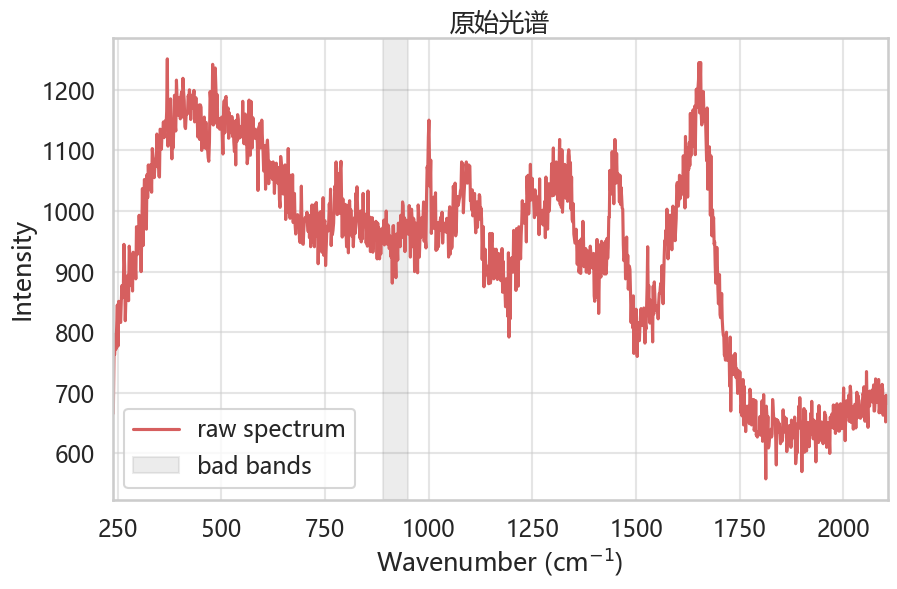

原始点数: 1340
原始波数范围: 238.26 -> 2106.71


In [3]:
# 1. 读取原始光谱
wn, sp = read_arc_data(sample_path)
if wn.size == 0 or sp.size == 0:
    raise ValueError(f"读取失败：{sample_path}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(wn, sp, color=sns.color_palette("muted")[3], label="raw spectrum")
add_bad_band_spans(ax, BAD_BANDS)
ax.set_xlim([wn.min(), wn.max()])
ax.set_title("原始光谱")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
ax.legend()
plt.show()

print(f"原始点数: {wn.size}")
print(f"原始波数范围: {wn.min():.2f} -> {wn.max():.2f}")


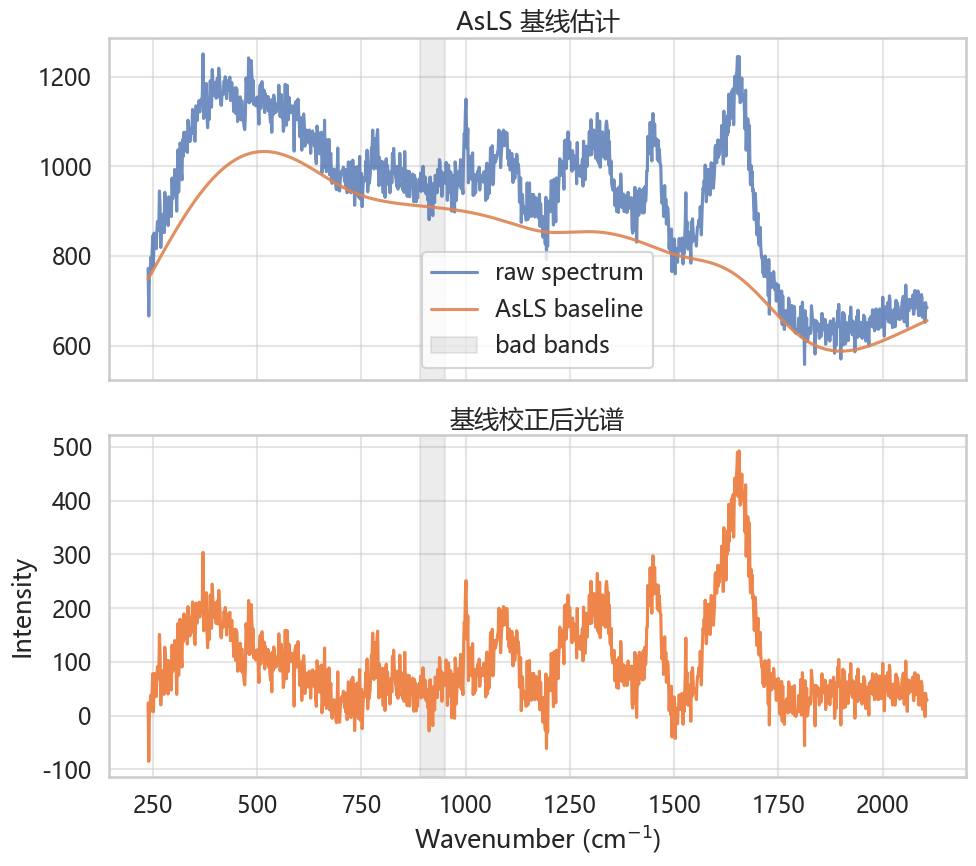

In [4]:
# 2. AsLS 基线校正：拟合时跳过坏波段
valid_mask_raw = build_valid_mask(wn, BAD_BANDS)
baseline = asls_baseline(
    sp,
    lam=cfg.asls_lam,
    p=cfg.asls_p,
    niter=cfg.asls_max_iter,
    valid_mask=valid_mask_raw,
)
sp_bc = sp - baseline

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
axes[0].plot(wn, sp, label="raw spectrum", alpha=0.8)
axes[0].plot(wn, baseline, label="AsLS baseline", alpha=0.9)
add_bad_band_spans(axes[0], BAD_BANDS)
axes[0].set_title("AsLS 基线估计")
axes[0].legend()

axes[1].plot(wn, sp_bc, color=sns.color_palette("muted")[1])
add_bad_band_spans(axes[1], BAD_BANDS)
axes[1].set_title("基线校正后光谱")
axes[1].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[1].set_ylabel("Intensity")
plt.tight_layout()
plt.show()


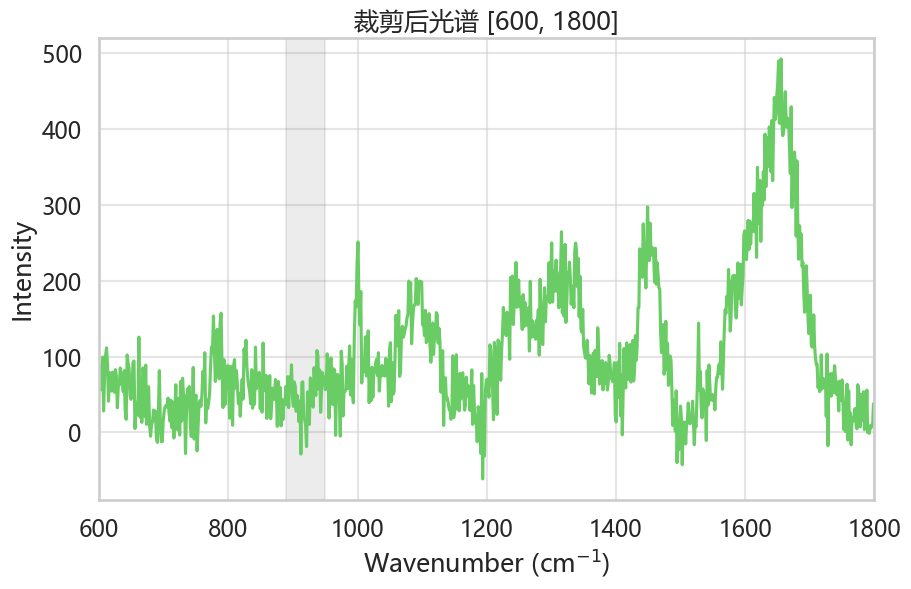

裁剪后点数: 860
裁剪后波数范围: 600.77 -> 1798.87


In [5]:
# 3. 按当前配置裁剪波段
mask_cut = (wn >= cfg.cut_min) & (wn <= cfg.cut_max)
wn_cut = wn[mask_cut]
sp_cut = sp_bc[mask_cut]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(wn_cut, sp_cut, color=sns.color_palette("muted")[2])
add_bad_band_spans(ax, BAD_BANDS)
ax.set_xlim([cfg.cut_min, cfg.cut_max])
ax.set_title(f"裁剪后光谱 [{cfg.cut_min}, {cfg.cut_max}]")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
plt.show()

print(f"裁剪后点数: {wn_cut.size}")
print(f"裁剪后波数范围: {wn_cut[0]:.2f} -> {wn_cut[-1]:.2f}")


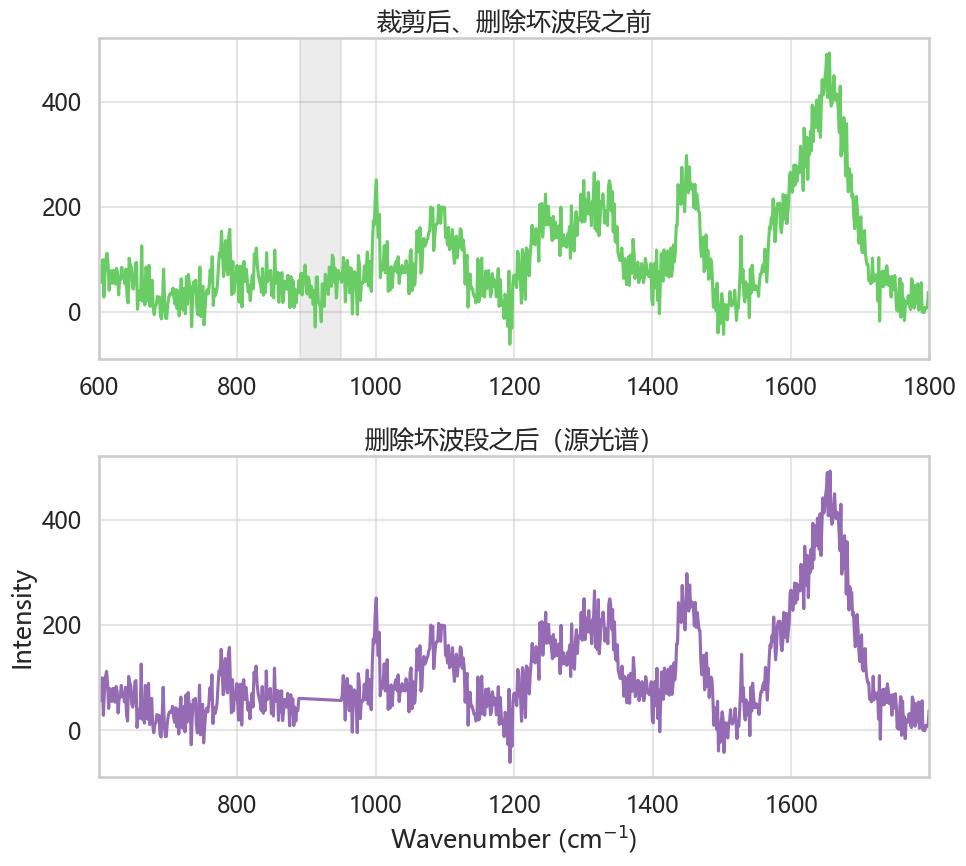

删除坏波段后点数: 819
删除点数: 41


In [6]:
# 4. 在裁剪结果上先删除坏波段
# 当前 raman.data 的真实做法是让坏波段同时退出插值与最终输出。
src_keep_mask = build_valid_mask(wn_cut, BAD_BANDS)
if src_keep_mask is None:
    src_keep_mask = np.ones_like(wn_cut, dtype=bool)

wn_valid = wn_cut[src_keep_mask]
sp_valid = sp_cut[src_keep_mask]

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=False)
axes[0].plot(wn_cut, sp_cut, color=sns.color_palette("muted")[2])
add_bad_band_spans(axes[0], BAD_BANDS)
axes[0].set_xlim([cfg.cut_min, cfg.cut_max])
axes[0].set_title("裁剪后、删除坏波段之前")

axes[1].plot(wn_valid, sp_valid, color=sns.color_palette("muted")[4])
axes[1].set_xlim([wn_valid.min(), wn_valid.max()])
axes[1].set_title("删除坏波段之后（源光谱）")
axes[1].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[1].set_ylabel("Intensity")
plt.tight_layout()
plt.show()

print(f"删除坏波段后点数: {sp_valid.shape[0]}")
print(f"删除点数: {(~src_keep_mask).sum()}")


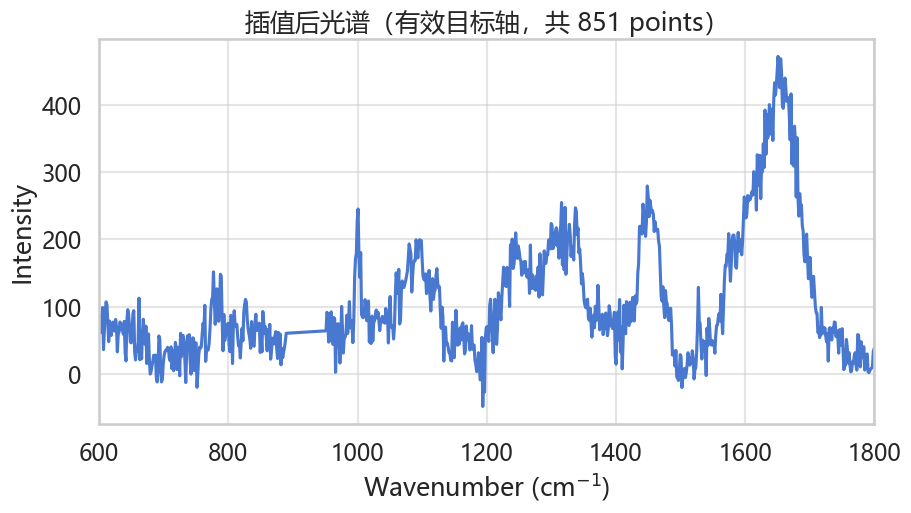

完整目标轴点数: 896
有效目标轴点数: 851


In [7]:
# 5. 只在保留后的目标波数坐标上插值
target_keep_mask = build_valid_mask(WN_REF, BAD_BANDS)
if target_keep_mask is None:
    target_keep_mask = np.ones_like(WN_REF, dtype=bool)

wn_processed = WN_REF[target_keep_mask]
sp_processed = np.interp(wn_processed, wn_valid, sp_valid)

fig, ax = plt.subplots()
ax.plot(wn_processed, sp_processed, color=sns.color_palette("muted")[0])
ax.set_xlim([wn_processed.min(), wn_processed.max()])
ax.set_title(f"插值后光谱（有效目标轴，共 {sp_processed.shape[0]} points）")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
plt.show()

print(f"完整目标轴点数: {WN_REF.shape[0]}")
print(f"有效目标轴点数: {wn_processed.shape[0]}")


wn 一致: True
sp 最大绝对误差: 0.000000e+00


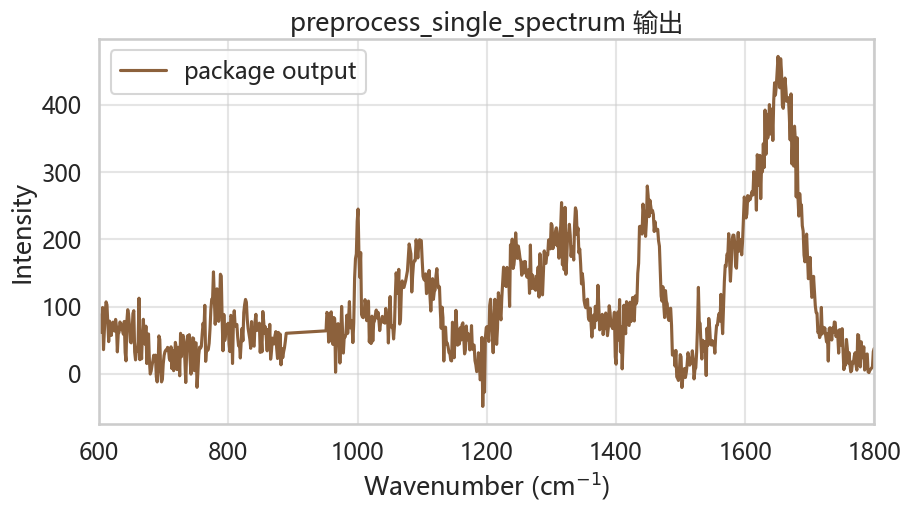

In [8]:
# 6. 直接调用库函数复核：应与上面的手工拆解结果一致
wn_pkg, sp_pkg = preprocess_single_spectrum(
    wn,
    sp,
    cut_min=cfg.cut_min,
    cut_max=cfg.cut_max,
    wn_ref=WN_REF,
    bad_bands=BAD_BANDS,
    asls_lam=cfg.asls_lam,
    asls_p=cfg.asls_p,
    asls_max_iter=cfg.asls_max_iter,
)

if wn_pkg is None or sp_pkg is None:
    raise RuntimeError("preprocess_single_spectrum 返回空结果，通常是裁剪后有效点数不足")

print(f"wn 一致: {np.array_equal(wn_processed, wn_pkg)}")
print(f"sp 最大绝对误差: {np.max(np.abs(sp_processed - sp_pkg)):.6e}")

fig, ax = plt.subplots()
ax.plot(wn_pkg, sp_pkg, color=sns.color_palette("muted")[5], label="package output")
ax.set_xlim([wn_pkg.min(), wn_pkg.max()])
ax.set_title("preprocess_single_spectrum 输出")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
ax.legend()
plt.show()


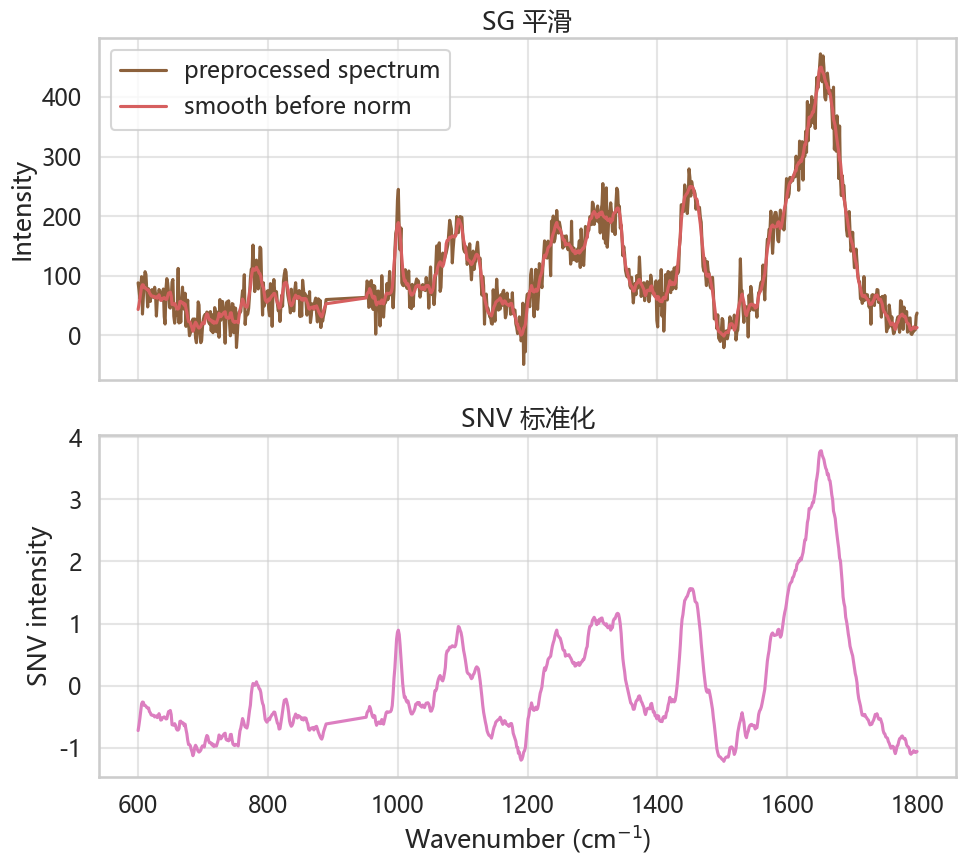

smooth 通道窗口: 15
smooth 通道多项式阶数: 3


In [10]:
# 7. smooth 通道展示：与 raman 中的 smooth 通道构建保持一致
# 当前 notebook 不做 raw 增强，因此这里等价于：预处理后主谱 -> SG smooth -> 当前标准化。
sg_smooth, _ = build_sg_kernels(train_cfg, torch.device("cpu"))
sp_pkg_tensor = torch.as_tensor(sp_pkg, dtype=torch.float32).view(1, 1, -1)
sp_smooth_pre_norm = F.conv1d(
    sp_pkg_tensor,
    sg_smooth,
    padding=train_cfg.win_smooth // 2,
)[0, 0].cpu().numpy()
sp_smooth = normalize_spectrum(sp_smooth_pre_norm, train_cfg.norm_method)

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
axes[0].plot(wn_pkg, sp_pkg, color=sns.color_palette("muted")[5], label="preprocessed spectrum")
axes[0].plot(wn_pkg, sp_smooth_pre_norm, color=sns.color_palette("muted")[3], label="smooth before norm")
axes[0].set_title("SG 平滑")
axes[0].set_ylabel("Intensity")
axes[0].legend()

axes[1].plot(wn_pkg, sp_smooth, color=sns.color_palette("muted")[6])
axes[1].set_title(f"{train_cfg.norm_method.upper()} 标准化")
axes[1].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[1].set_ylabel(f"{train_cfg.norm_method.upper()} intensity")
plt.tight_layout()
plt.show()

print(f"smooth 通道窗口: {train_cfg.win_smooth}")
print("smooth 通道多项式阶数: 3")


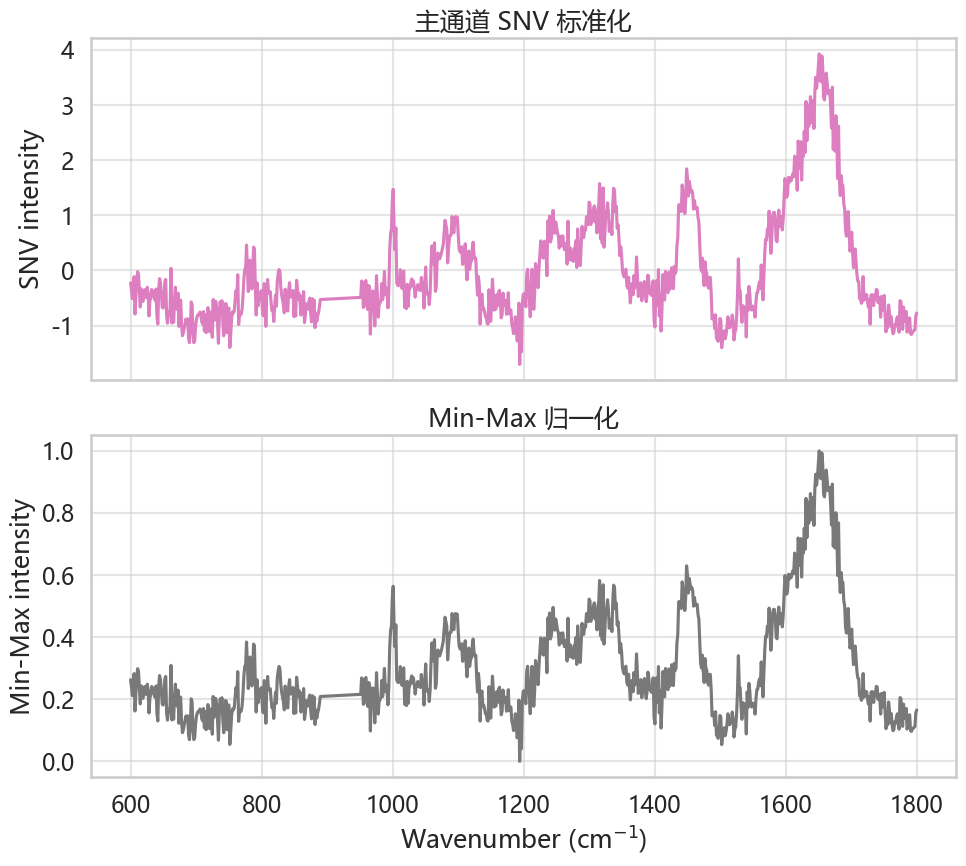

当前离线真实流程：原始光谱 -> AsLS -> 裁剪 -> 删除 bad_bands -> 在有效目标轴上插值 -> 写入 train / test
当前 raman.Config.norm_method = 'snv'


In [11]:
# 8. 主通道标准化展示：这是模型输入内容，不是离线落盘内容
sp_norm = normalize_spectrum(sp_pkg, train_cfg.norm_method)
sp_minmax = minmax_normalize(sp_pkg)

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
axes[0].plot(wn_pkg, sp_norm, color=sns.color_palette("muted")[6])
axes[0].set_title(f"主通道 {train_cfg.norm_method.upper()} 标准化")
axes[0].set_ylabel(f"{train_cfg.norm_method.upper()} intensity")

axes[1].plot(wn_pkg, sp_minmax, color=sns.color_palette("muted")[7])
axes[1].set_title("Min-Max 归一化")
axes[1].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[1].set_ylabel("Min-Max intensity")
plt.tight_layout()
plt.show()

print("当前离线真实流程：原始光谱 -> AsLS -> 裁剪 -> 删除 bad_bands -> 在有效目标轴上插值 -> 写入 train / test")
print(f"当前 raman.Config.norm_method = {train_cfg.norm_method!r}")
